In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import math
from sklearn.preprocessing import RobustScaler
import pickle

from utils import *
%load_ext autoreload
%autoreload 2

dbscan is good for outliers (-1 db cluster), not for cluster (2% flag)

karen segmentation

association rules for each cluster (vegetarian cluster), tweak parameters for each, use basket for recomendation (cross basket, after clustering), use practical example from week 11 (no train_test_split)

pca not that good

tsne for visualization maybe, umap for cluster visualization (good definitions)



In [4]:
customer = pd.read_csv('data/customer_info.csv')
customer.head()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [5]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  str    
 2   customer_gender                          33038 non-null  str    
 3   customer_birthdate                       32873 non-null  str    
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377 non-null  

In [6]:
customer.isnull().sum()

customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

In [7]:
num_cols = customer.select_dtypes(include=[np.number]).drop('customer_id', axis=1).columns.tolist()
cat_cols = customer.select_dtypes(include=[object])
display(num_cols)
display(cat_cols)

/var/folders/gf/x3p5nfmx59g97hz4jnt10zw80000gn/T/ipykernel_69817/1077923538.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = customer.select_dtypes(include=[object])


['kids_home',
 'teens_home',
 'number_complaints',
 'distinct_stores_visited',
 'lifetime_spend_groceries',
 'lifetime_spend_electronics',
 'typical_hour',
 'lifetime_spend_vegetables',
 'lifetime_spend_nonalcohol_drinks',
 'lifetime_spend_alcohol_drinks',
 'lifetime_spend_meat',
 'lifetime_spend_fish',
 'lifetime_spend_hygiene',
 'lifetime_spend_videogames',
 'lifetime_spend_petfood',
 'lifetime_total_distinct_products',
 'percentage_of_products_bought_promotion',
 'year_first_transaction',
 'loyalty_card_number',
 'latitude',
 'longitude']

,customer_name,customer_gender,customer_birthdate
0,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM
1,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM
2,Msc. Antonio Campbell,male,09/10/1971 10:07 AM
3,John Kelling,male,10/23/1982 11:20 AM
4,Arthur Dematteo,male,08/04/1969 10:22 PM
...,...,...,...
33033,Joshua Howard,male,05/16/1973 02:04 PM
33034,Anthony Hines,male,05/10/1955 01:19 AM
33035,Edna Hasselman,female,05/15/1945 11:09 PM
33036,George Kramer,male,05/25/1951 09:02 PM


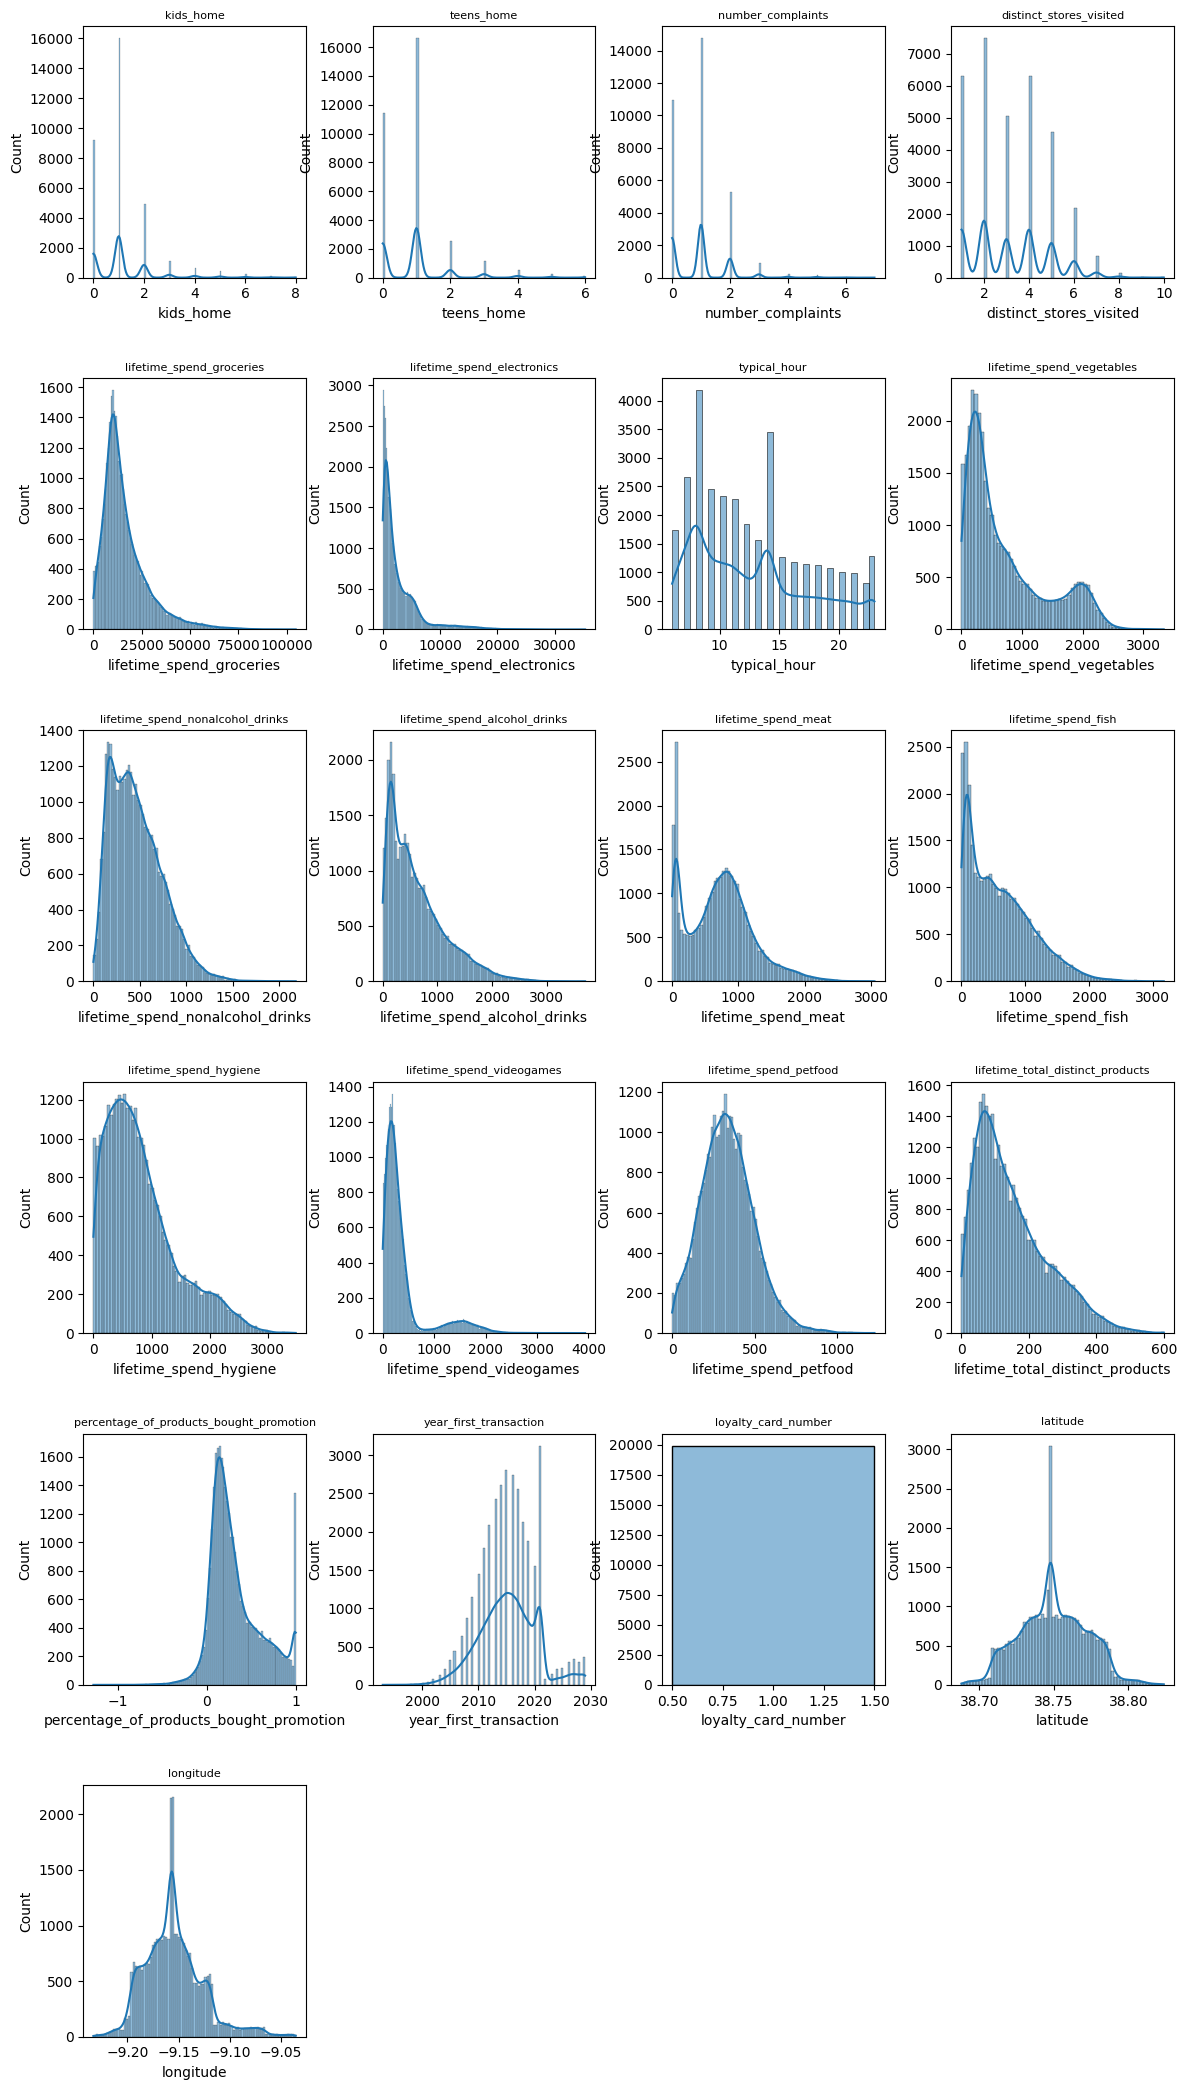

In [8]:
plot_distribution_grid(customer, num_cols)

We won't include the column 'loyalty_card_number' in the dataset, as it has only 1 value, so it it brings no value to the model.

In [51]:
customer.drop('loyalty_card_number', axis=1, inplace=True)
num_cols.remove('loyalty_card_number')

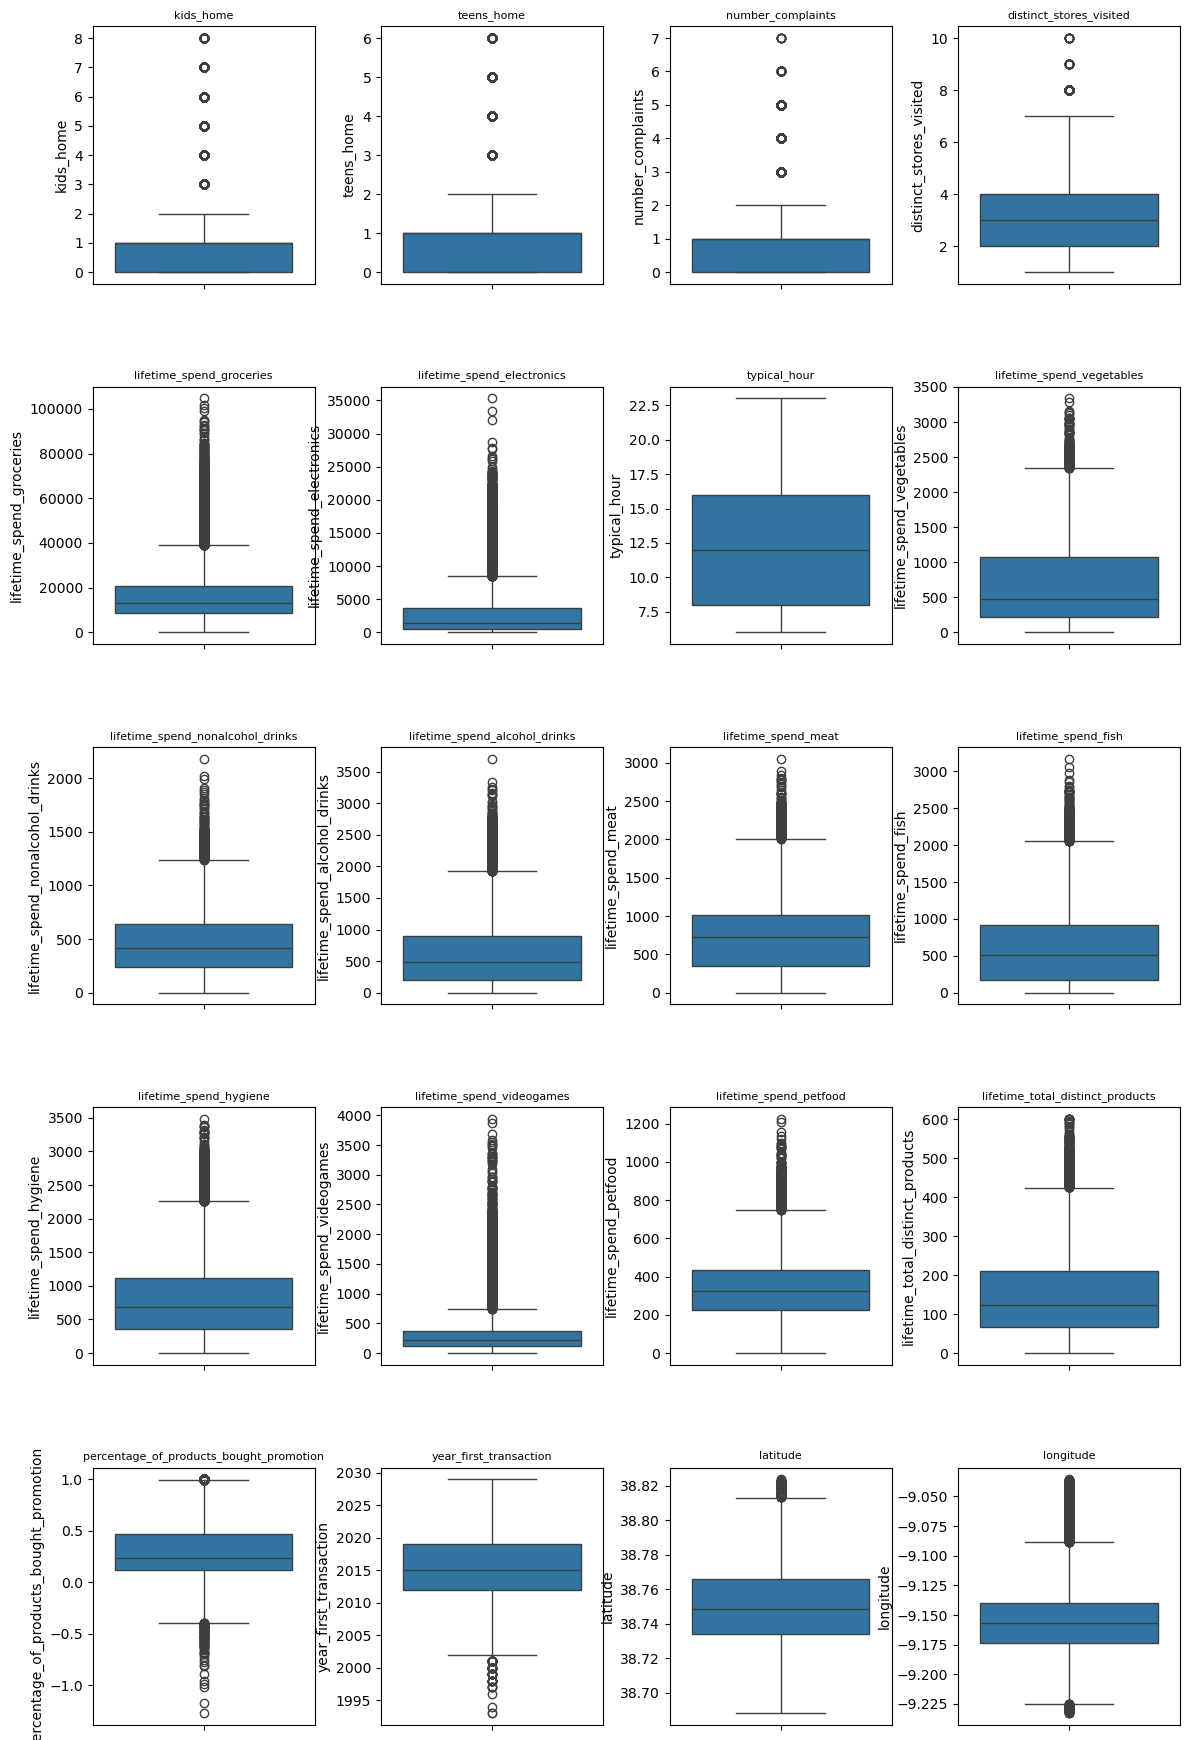

In [52]:
plot_boxplot_grid(customer, num_cols)

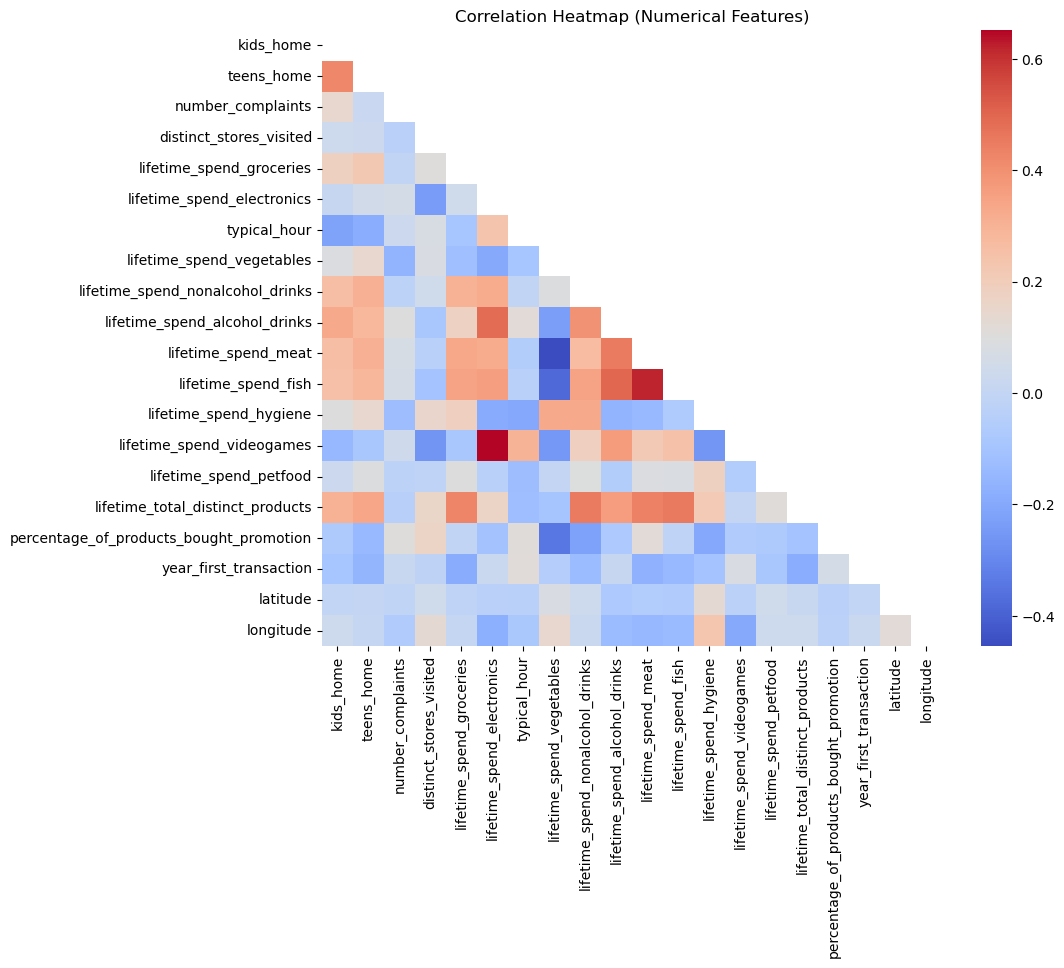

In [60]:
plot_correlation_heatmap(customer, num_cols)